In [6]:
# unit test CAS_preprocess_01_unskew_image
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
from natsort import natsorted
from PIL import Image
from scipy.signal import find_peaks
import cv2 as cv
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import argparse
from datetime import datetime as dt
import h5py
import sys
import ast

code_dir = Path('/code/')
sys.path.append(str(code_dir))

import CAS_preprocess_01_unskew_image as unskew_image
%matplotlib inline

SAT_VAL = 12000
FIBER_WIDTH = 60

In [2]:
# Test load_session_paths
# New .py version
data_dir = '/data/'
session_id = os.listdir(data_dir)[0]
path, calib_path = unskew_image.load_session_paths(data_dir, session_id)

# Original .ipynb version
path_1 = os.path.join(data_dir,session_id)
calib_path_1 = os.path.join(path,'fib/CalibrationFiles')

# Compare
assert path == path_1, "Paths differ!"
assert calib_path == calib_path_1, "Calibration paths differ!"

In [3]:
# Test load_calibration_metadata
# New .py version
metadata = unskew_image.load_calibration_metadata(calib_path)

# Original .ipynb version
metadata_file_1 = glob.glob(os.path.join(calib_path_1,'*.csv'))
session_params_file_1 = [f for f in metadata_file_1 if 'session_params' in os.path.basename(f)]
metadata_1 = pd.read_csv(session_params_file_1[0])

# Compare
pd.testing.assert_frame_equal(metadata, metadata_1)

In [4]:
# Test load_and_average_tiff
# New .py version
tiff_dir = os.path.join(calib_path, 'Tiffs')
img2d = unskew_image.load_and_average_tiff(tiff_dir)

# Original .ipynb version
tiff_dir_1 = os.path.join(calib_path_1,'Tiffs')
tiff_files_1 = os.listdir(tiff_dir_1)
tiff_files_1 = np.array(natsorted(tiff_files_1))
# take the first tiff file and build its full path
tiff_file_path_1 = os.path.join(tiff_dir_1,tiff_files_1[0])
# open the tiff using python imaging library
tiff_1 = Image.open(tiff_file_path_1)
image_sequence_1 = []
# Extract all frames from the first multi-frame tiff into an image_sequence list of numpy arrays (each represents one frame/image)
while True:
    try:
        image_sequence_1.append(np.array(tiff_1))
        tiff_1.seek(tiff_1.tell() + 1)
    except EOFError:
        break
print('\nnumber of images in tiff: ')
print(len(image_sequence_1))
img_1 = np.array(image_sequence_1) # convert the list of frames into a 3D numpy array (num_frames, height, width)
img2d_1 = img_1.mean(axis=0) # average across all frames (axis=0) to create a single 2D image

# Compare
assert np.array_equal(img2d, img2d_1, equal_nan=True), "images differ"


number of images in tiff: 
1000


In [5]:
# Camera offsets
# New .py version
Xoffset = metadata.XOffset[0]
Yoffset = metadata.YOffset[0]

# Original .ipynb version
Xoffset_1 = metadata_1.XOffset[0]
Yoffset_1 = metadata_1.YOffset[0]

# Compare
assert Xoffset == Xoffset_1, "X offsets differ"
assert Yoffset == Yoffset_1, "Y offsets differ"

In [6]:
# Test find_laser_positions
# New .py version
h_peaks, v_peaks, img_to_unskew = unskew_image.find_laser_positions(img2d)

# Original .ipynb version
img_to_unskew_1 = np.array(img2d_1)
h_orig_line_1 = np.mean(img_to_unskew_1,axis=0) # average the image vertically, laser spots will appear as peaks in a horizontal 1D profile
h_orig_laser_pix_1, _ = find_peaks(h_orig_line_1, height=2000, distance=100) #find peaks brighter than 2000 and at least 100 pixels apart
count = 0 # Initialize counter for laser number
sat_val = 12000 # Set intensity threshold for pixels that contain lasers
v_orig_laser_pix_1 = np.zeros(np.size(h_orig_laser_pix_1)) # Initialize array to store vertical positions of each laser
for l in h_orig_laser_pix_1: # Run the loop for each laser's horizontal position 'l'
    v_orig_line_1 = img_to_unskew_1[:,l] # Extract a vertical column from the original calibration image at each position 'l'
    v_orig_line_1[v_orig_line_1<sat_val] = 0 # Set all pixels below the sat_val threshold to 0 to isolate the brightest spots
    idx = np.nonzero(np.diff(v_orig_line_1))[0] # Find indices where bright spots transition to 0 (top and bottom edges of the laser spot)
    v_orig_laser_pix_1[count] = np.round((idx[0]+idx[-1])/2) # Find the laser's vertical midpoint by averaging its top and bottom edges
    count +=1 # Increase the laser counter by 1

# Compare
assert np.array_equal(h_peaks, h_orig_laser_pix_1), "h_peaks differ"
assert np.array_equal(v_peaks, v_orig_laser_pix_1), "v_peaks differ"
assert np.array_equal(img_to_unskew, img_to_unskew_1), "images to unskew differ"
assert np.array_equal(img2d, img2d_1, equal_nan=True), "images differ"

In [7]:
print(h_peaks)
print(h_orig_laser_pix_1)

print(v_peaks)
print(v_orig_laser_pix_1)

[ 432  561  729  870 1277]
[ 432  561  729  870 1277]
[112 112 108 105  92]
[112. 112. 108. 105.  92.]


In [8]:
print(np.array_equal(img2d, img_to_unskew, equal_nan=True))
print(np.array_equal(img2d_1, img_to_unskew_1, equal_nan=True))

False
False


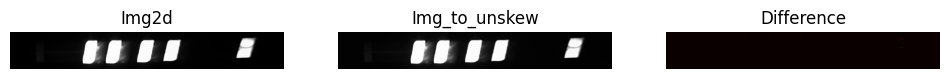

456
11709.914


In [9]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img2d, cmap='gray')
plt.title('Img2d')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_to_unskew, cmap='gray')
plt.title('Img_to_unskew')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(np.abs(img2d - img_to_unskew), cmap='hot')
plt.title('Difference')
plt.axis('off')

plt.show()

diff = img2d - img_to_unskew
num_diff_pixels = np.count_nonzero(diff)
print(num_diff_pixels)
max_diff = np.max(np.abs(img2d - img_to_unskew))
print(max_diff)

In [10]:
# # Test image rotation
# # New .py version
# img_rotated, theta_r = unskew_image.rotate_image(img_to_unskew, h_peaks, v_peaks)

# # Original .ipynb version
# theta_r_1 = np.rad2deg(np.arctan((v_orig_laser_pix_1[-2]-v_orig_laser_pix_1[0])/(h_orig_laser_pix_1[-2]-h_orig_laser_pix_1[0])))
# # Rotate image by the calculated angle using openCV
# rows,cols = img_to_unskew_1.shape 
# M = cv.getRotationMatrix2D(((cols-1)/2.0,(rows-1)/2.0),theta_r_1,1) # create a rotation transformation matrix
# img_rotated_1 = cv.warpAffine(img_to_unskew_1,M,(cols,rows)) # apply the rotation transformation to unskew the image

# print(theta_r)
# print(theta_r_1)

# assert np.array_equal(img_rotated, img_rotated_1), "rotated images differ"
# assert theta_r == theta_r_1, "rotation angles differ"
# assert np.array_equal(img_to_unskew, img_to_unskew_1), "images to unskew differ"

In [11]:
# Test image rotation
# New .py version
img_rotated, theta_r = unskew_image.rotate_image(img_to_unskew, h_peaks, v_peaks)

# Original .ipynb version
theta_r_1 = np.rad2deg(np.arctan((v_orig_laser_pix_1[-2]-v_orig_laser_pix_1[0])/(h_orig_laser_pix_1[-2]-h_orig_laser_pix_1[0])))
# Rotate image by the calculated angle using openCV
rows,cols = img2d_1.shape 
M = cv.getRotationMatrix2D(((cols-1)/2.0,(rows-1)/2.0),theta_r_1,1) # create a rotation transformation matrix
img_rotated_1 = cv.warpAffine(img_to_unskew_1,M,(cols,rows)) # apply the rotation transformation to unskew the image

print(theta_r)
print(theta_r_1)

assert np.array_equal(img_rotated, img_rotated_1), "rotated images differ"
assert theta_r == theta_r_1, "rotation angles differ"
assert np.array_equal(img_to_unskew, img_to_unskew_1), "images to unskew differ"

-0.9156080256587755
-0.9156080256587755


In [12]:
print(h_peaks)
print(v_peaks)


[ 432  561  729  870 1277]
[112 112 108 105  92]


In [13]:
# Test analyze_laser
img_rotated_copy = img_rotated.copy()

# Alt .py version

h_line = np.mean(img_rotated, axis=0)
h_peaks_rot, _ = find_peaks(h_line, height=2000, distance=100)
v_width1, h_width1 = unskew_image.analyze_laser(img_rotated, h_peaks_rot, use_laser=1)
v_width2, h_width2 = unskew_image.analyze_laser(img_rotated, h_peaks_rot, use_laser=2)
print(v_width1, h_width1, v_width2, h_width2)

# Original .ipynb version
h_line_1 = np.mean(img_rotated_1,axis=0)
h_laser_pix, _ = find_peaks(h_line_1, height=2000, distance=100)
def analyze_laser(img_rotated, h_laser_pix, use_laser, sat_val, fiber_width=60):
    """Finds and plots the top/bottom edges of a fiber for a given laser."""
    
    # --- Vertical boundaries ---
    v_line = img_rotated[:, h_laser_pix[use_laser]] # extract one vertical column of pixel intensities at the laser's x-position
    v_line[v_line < sat_val] = 0 # set values below the intensity threshold to zero
    idx = np.nonzero(np.diff(v_line))[0] # find locations where intensity changes (edge of laser)
    v_width = [int(idx[0]), int(idx[-1])] # store the top and bottom y-coordinates of the laser
    
    # --- Horizontal boundaries (top and bottom) ---
    h_width = []
    for position, label, offset in zip(
        [v_width[0] + 5, v_width[1] - 5],
        ["Top", "Bottom"],
        ["h_top", "h_bot"]
    ):
        # Extract horizontal cross-section
        h_line = img_rotated[
            position,
            h_laser_pix[use_laser] - fiber_width : h_laser_pix[use_laser] + fiber_width
        ]
        h_line[h_line < sat_val] = 0
        h_edges = np.nonzero(np.diff(h_line))[0]
        h_edge = int(h_edges[0])

       #  # --- Plot for visualization --- 
       #  f, ax = plt.subplots(figsize=(4, 2))
       #  ax.plot(h_line)
       #  ax.set(
       #      xlabel="Camera pixels",
       #      ylabel="Saturation intensity",
       #      title=f"Laser {use_laser + 1} Fiber {label}"
       #  )
       #  plt.show()

        # Convert to absolute coordinates
        h_width.append(int(h_laser_pix[use_laser] - fiber_width + h_edge))

    # --- Print summary ---
    print(f"Laser {use_laser + 1}")
    print(f"  Vertical pixel indices (top, bottom): {v_width}")
    print(f"  Horizontal pixel indices (top left, bottom left): {h_width}\n\n")
    
    return v_width, h_width

# Find fiber coordinates for laser 2
use_laser_1 = 1
v_width1_orig, h_width1_orig = analyze_laser(img_rotated_1, h_laser_pix, use_laser_1, sat_val, fiber_width=60)

# Find fiber coordinates for laser 3
use_laser_2 = 2
v_width2_orig, h_width2_orig = analyze_laser(img_rotated_1, h_laser_pix, use_laser_2, sat_val, fiber_width=60)
print(v_width1_orig, h_width1_orig, v_width2_orig, h_width2_orig)

assert v_width1 == v_width1_orig
assert h_width1 == h_width1_orig
assert v_width2 == v_width2_orig
assert h_width2 == h_width2_orig
assert np.array_equal(img_rotated, img_rotated_1), "img_rotated changes after going through analyze_laser function" 

[47, 170] [548, 519] [49, 166] [719, 689]
Laser 2
  Vertical pixel indices (top, bottom): [47, 170]
  Horizontal pixel indices (top left, bottom left): [548, 519]


Laser 3
  Vertical pixel indices (top, bottom): [49, 166]
  Horizontal pixel indices (top left, bottom left): [719, 689]


[47, 170] [548, 519] [49, 166] [719, 689]


In [14]:
# Define affine points
pt1, pt2, pt3 = [h_width1[0], v_width1[0]], [h_width1[1], v_width1[1]], [h_width2[0], v_width2[0]]
pt4, pt5, pt6 = [h_width1[1], v_width1[0]], [h_width1[1], v_width1[1]], [h_width2[1], v_width2[0]]

print(pt1, pt2, pt3, pt4, pt5, pt6)

[548, 47] [519, 170] [719, 49] [519, 47] [519, 170] [689, 49]


In [15]:
# Test perform_affine_transform
# New .py version
img_final = unskew_image.perform_affine_transform(img_rotated, [pt1, pt2, pt3], [pt4, pt5, pt6])

# Original .ipynb version
rows,cols = img_rotated_1.shape # get height and width of the image to define the output size in warpAffine
pts1 = np.float32([pt1, pt2, pt3]) # source points (from original image)
pts2 = np.float32([pt4, pt5, pt6]) # destination points (where those points should end up in the output image)
M = cv.getAffineTransform(pts1,pts2) # compute a 2x3 affine transformation matrix
img_final_1 = cv.warpAffine(img_rotated_1,M,(cols,rows)) # apply the transfomration to the whole image

assert np.array_equal(img_final, img_final_1)

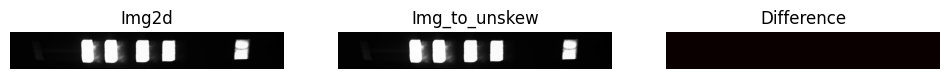

0
0.0


In [16]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img_final, cmap='gray')
plt.title('Img2d')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_final_1, cmap='gray')
plt.title('Img_to_unskew')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(np.abs(img_final - img_final_1), cmap='hot')
plt.title('Difference')
plt.axis('off')

plt.show()

diff = img_final - img_final_1
num_diff_pixels = np.count_nonzero(diff)
print(num_diff_pixels)
max_diff = np.max(np.abs(img_final - img_final_1))
print(max_diff)

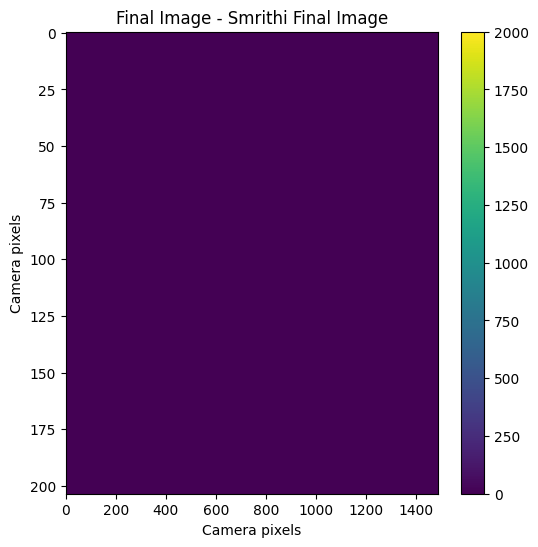

In [17]:
f,ax = plt.subplots(figsize=(6,6))
i = ax.imshow(np.abs(img_final - img_final_1),  aspect='auto', vmin=0, vmax=2000)
ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title='Final Image - Smrithi Final Image')
ax.grid(False)
f.colorbar(i,ax=ax)
plt.show()

In [18]:
# Store fiber boundaries
# New .py version
h_line_final = np.mean(img_final, axis=0)
h_peaks_final, _ = find_peaks(h_line_final, height=2000, distance=100)
fiber1, fiber2 = unskew_image.store_fiber_boundaries(img_final, h_peaks_final, use_laser=2)


# Original .ipynb version
# Create a 1D array representing mean brightness at each x-position
h_line_new = np.mean(img_final_1,axis=0) # calculate the average intensity along each column of the final image
h_laser_pix_new, _ = find_peaks(h_line_new, height=2000, distance=100) # identify x-positions of peaks above 2000 and at least 100 pixels apart
v_line = img_final_1[:,h_laser_pix_new[use_laser_2]]
v_line[v_line < sat_val] = 0
idx = np.nonzero(np.diff(v_line))[0]
v_width_orig = [int(idx[0]), int(idx[-1])]
fiber1_top = v_width_orig[0] + 20 # 20 pixels below the top edge
fiber1_bottom = v_width_orig[0] + 50 - 10 # 40 pixels below the top edge
# Define vertical bounds of the second fiber
fiber2_top = v_width_orig[1] - 50 + 10 # 40 pixels above the bottom edge
fiber2_bottom = v_width_orig[1] - 20 # 20 pixels above the bottom edge

fiber1_orig = [fiber1_top, fiber1_bottom]
fiber2_orig = [fiber2_top, fiber2_bottom]

assert fiber1 == fiber1_orig
assert fiber2 == fiber2_orig

In [20]:
print(fiber1, fiber2)
print(fiber1_orig, fiber2_orig)

[69, 89] [126, 146]
[69, 89] [126, 146]


In [21]:
assert np.array_equal(img_final, img_final_1)

In [22]:
print(Xoffset)
print(Yoffset)

348
524


In [23]:
# Save the affine transformed points and fiber locations
pt1[0] = int(pt1[0] + Xoffset)
pt2[0] = int(pt2[0] + Xoffset)
pt3[0] = int(pt3[0] + Xoffset)
pt4[0] = int(pt4[0] + Xoffset)
pt5[0] = int(pt5[0] + Xoffset)
pt6[0] = int(pt6[0] + Xoffset)
pt1[1] = int(pt1[1] + Yoffset)
pt2[1] = int(pt2[1] + Yoffset)
pt3[1] = int(pt3[1] + Yoffset)
pt4[1] = int(pt4[1] + Yoffset)
pt5[1] = int(pt5[1] + Yoffset)
pt6[1] = int(pt6[1] + Yoffset)

fiber1[0] = int(fiber1[0] + Yoffset)
fiber1[1] = int(fiber1[1] + Yoffset)
fiber2[0] = int(fiber2[0] + Yoffset)
fiber2[1] = int(fiber2[1] + Yoffset)

# Save transformed image for wavelength calibration
img_final_1 = img_final_1.astype(int)
results_dir = Path('/results/')
results_dir.mkdir(parents=True, exist_ok=True)  # ensure folder exists

output_file = results_dir / "CalibrationImage_ipynb.tiff"
cv.imwrite(str(output_file), img_final_1)

with open(results_dir / 'calibration_ipynb.txt','w') as f:
    f.write(f'rot_tform_thetaR = {theta_r_1}\n')
    f.write(f'aff_tform_pt1 = {pt1}\n')
    f.write(f'aff_tform_pt2 = {pt2}\n')
    f.write(f'aff_tform_pt3 = {pt3}\n')
    f.write(f'aff_tform_pt4 = {pt4}\n')
    f.write(f'aff_tform_pt5 = {pt5}\n')
    f.write(f'aff_tform_pt6 = {pt6}\n')
    f.write(f'fiber1_pixels = {fiber1}\n')
    f.write(f'fiber2_pixels = {fiber2}\n')
    f.write(f'calib_Xoffset = {Xoffset}\n')

In [24]:
# Save results
img_final = img_final.astype(int)
results_dir = Path('/results/')
unskew_image.save_results(img_final, theta_r, [pt1, pt2, pt3, pt4, pt5, pt6], [fiber1, fiber2], Xoffset, Yoffset, results_dir)



In [25]:
assert np.array_equal(img_final, img_final_1)

In [7]:
results_dir = Path('/results/')
print(f"Results saved to {results_dir}")
print(f"  - CalibrationImage.tiff")
print(f"  - calibration.txt")

Results saved to /results
  - CalibrationImage.tiff
  - calibration.txt
